# E-commerce Sales Analysis

**Objective:** Analyze transactions to identify revenue drivers, seasonal patterns, and high-value customer segments.

**Dataset:** UCI Online Retail II (2009-2011)  
**Author:** Hamdi Ahmed
**Date:** 26/06/2026

## 1. Setup and Data Loading

In [1]:
import duckdb
import pandas as pd

cleaned = pd.read_csv('../data/processed/cleaned.csv')
registered = pd.read_csv('../data/processed/registered_only.csv')

from IPython.display import HTML, display


display(HTML("""
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js"></script>
<script>window._chartjsLoaded = true;</script>
"""))


print(f"Loaded {len(cleaned):,} rows for cleaned data")
print(f"Loaded {len(registered):,} rows for cleaned data with registered customers only")
pd.set_option('display.float_format', '{:,.2f}'.format)

Loaded 984,825 rows for cleaned data
Loaded 763,863 rows for cleaned data with registered customers only


In [2]:
con = duckdb.connect()
con.register('registered', registered)

print("Columns:", list(registered.columns))

Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country', 'is_guest', 'Revenue', 'p99_qty', 'p99_price', 'p99_revenue', 'Year', 'Month', 'DayOfWeek', 'Hour', 'IsWeekend', 'WeekStart', 'MonthStart']


## 2. Revenue Analysis

In [3]:
# Monthly Revenue

con.execute("""
    SELECT
        strftime(CAST(InvoiceDate AS DATE), '%b-%Y') AS month_year,
        SUM(Revenue) as total_revenue,
        COUNT(DISTINCT Invoice) orders,
        COUNT(DISTINCT CustomerID) as customers
    FROM cleaned
    GROUP BY strftime(CAST(InvoiceDate AS DATE), '%b-%Y')
    ORDER BY strftime(CAST(InvoiceDate AS DATE), '%b-%Y')
""").fetchdf()

,month_year,total_revenue,orders,customers
0,Apr-2010,"511,933.75",1398,925
1,Apr-2011,"410,384.28",1194,832
2,Aug-2010,"489,691.24",1354,890
3,Aug-2011,"537,732.84",1299,911
4,Dec-2009,"619,535.97",1611,936
5,Dec-2010,"578,965.00",1487,856
6,Dec-2011,"336,199.92",789,600
7,Feb-2010,"408,900.24",1152,758
8,Feb-2011,"399,063.93",1057,737
9,Jan-2010,"413,870.96",1022,693


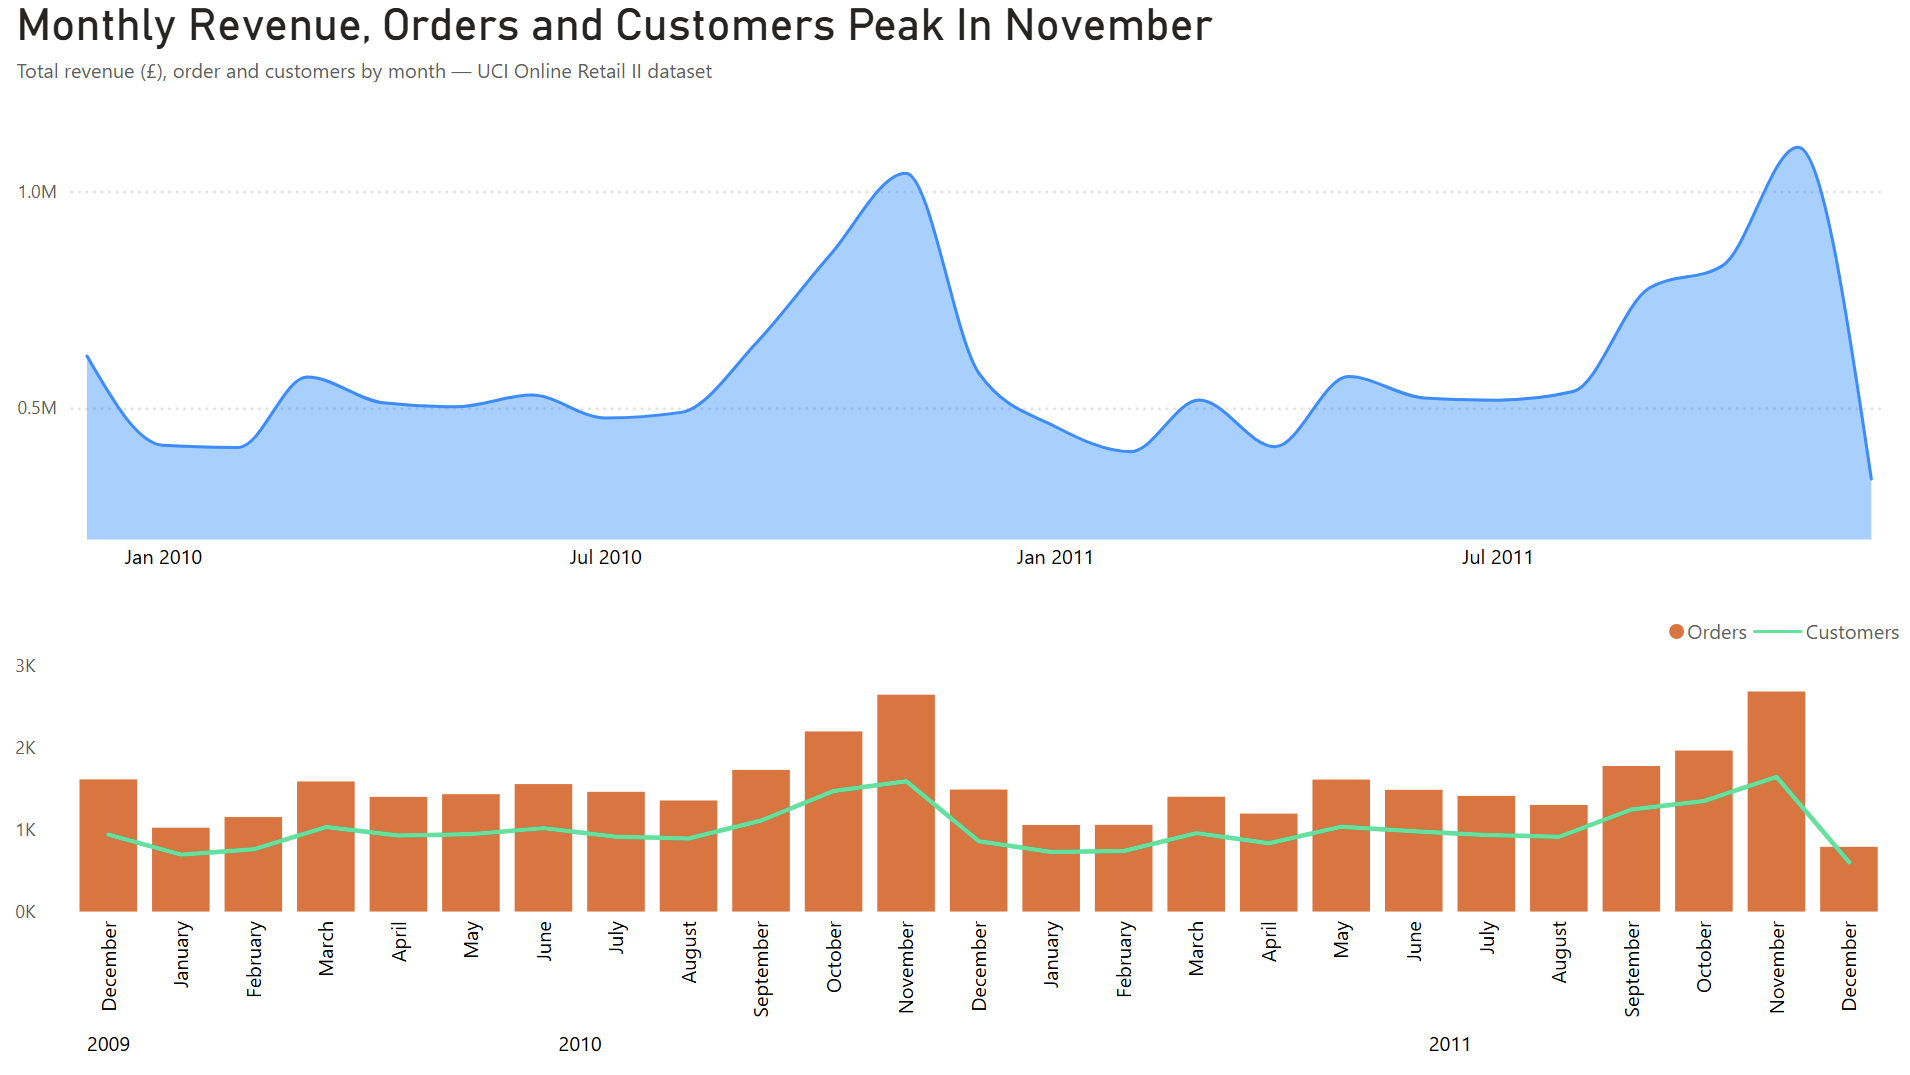

In [4]:
from IPython.display import Image
Image('../docs/img/monthly_rev_orders_cust.png', width=1000, height=600)

In [5]:
con.execute("""
    WITH monthly_totals AS (
        SELECT
            strftime(CAST(InvoiceDate AS DATE), '%B') AS month_name,
            SUM(Revenue) AS total_revenue,
            COUNT(DISTINCT Invoice) AS orders,
            COUNT(DISTINCT CustomerID) AS customers
        FROM cleaned
        GROUP BY 
            strftime(CAST(InvoiceDate AS DATE), '%B')
    )
    SELECT
        month_name as "Month",
        ROUND(AVG(total_revenue), 2)  AS "Average Revenue",
        ROUND(AVG(orders), 2) AS "Average Number of Orders",
        ROUND(AVG(customers), 2) AS "Average Number of Customers"
    FROM monthly_totals
    GROUP BY month_name
    ORDER BY AVG(total_revenue) DESC
""").fetchdf()

,Month,Average Revenue,Average Number of Orders,Average Number of Customers
0,November,"2,143,202.45","5,327.00","2,548.00"
1,October,"1,680,315.22","4,159.00","2,340.00"
2,December,"1,534,700.89","3,887.00","1,775.00"
3,September,"1,427,058.05","3,501.00","1,941.00"
4,March,"1,089,732.11","2,986.00","1,651.00"
5,May,"1,075,083.01","3,040.00","1,643.00"
6,June,"1,052,565.51","3,038.00","1,663.00"
7,August,"1,027,424.08","2,653.00","1,480.00"
8,July,"994,544.99","2,870.00","1,531.00"
9,April,"922,318.03","2,592.00","1,488.00"


In [6]:
from IPython.display import IFrame

IFrame('../docs/img/average_monthly_revenue_chart.html', width=900, height=520)

In [7]:
totals = con.execute("""
    SELECT
        SUM(Revenue) as total_revenue,
        COUNT(DISTINCT Invoice) AS total_orders,
        COUNT(DISTINCT CustomerID) AS total_customers
    FROM
        cleaned
""").fetchdf()

totals

,total_revenue,total_orders,total_customers
0,"14,625,928.52",38339,5780


## 4. Customer Segmentation 

In [8]:
# Recency = Number of days since last purchase

# Frequency = Number of purchases made

# Monetary = Total amount spent


con.execute("""
    SELECT
        CustomerID,
        DATE_DIFF('day',
            MAX(CAST(InvoiceDate AS DATE)),
            (SELECT MAX(CAST(InvoiceDate AS DATE)) + INTERVAL '1 day' FROM registered)
        ) AS Recency,
        COUNT(DISTINCT Invoice) AS Frequency,
        SUM(Revenue) AS Monetary
    FROM registered
    GROUP BY CustomerID
""").fetchdf()

,CustomerID,Recency,Frequency,Monetary
0,"14,388.00",11,16,"6,388.20"
1,"15,173.00",381,7,"1,494.60"
2,"16,186.00",23,26,"8,718.43"
3,"16,161.00",2,43,"12,580.06"
4,"17,902.00",547,1,187.60
...,...,...,...,...
5775,"13,380.00",433,1,62.40
5776,"17,331.00",124,1,175.20
5777,"16,953.00",31,1,20.80
5778,"13,788.00",506,1,3.75


In [9]:
rfm_raw = con.execute("""
    SELECT
        CustomerID,
        DATE_DIFF('day',
            MAX(CAST(InvoiceDate AS DATE)),
            (SELECT MAX(CAST(InvoiceDate AS DATE)) + INTERVAL '1 day' FROM registered)
        ) AS Recency,
        COUNT(DISTINCT Invoice) AS Frequency,
        SUM(Revenue) AS Monetary
    FROM registered
    GROUP BY CustomerID
""").fetchdf()

In [10]:
rfm_columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

query_parts = []

for column in rfm_columns:
    piece = f"""
    SELECT 
        '{column}' as column_name,
        COUNT(*) as total,
        MIN({column}) as min,
        QUANTILE_CONT({column},0.25) as qntile_25,
        QUANTILE_CONT({column},0.5) as median,
        QUANTILE_CONT({column},0.75) as qntile_75,
        MAX({column}) as max,
        ROUND(AVG({column}),2) as mean  
    FROM 
        rfm_raw
    """
    query_parts.append(piece)
rfm_distribution_query = " UNION ALL ".join(query_parts)

In [11]:
rfm_distribution_df = con.execute(rfm_distribution_query).fetchdf()
rfm_distribution_df

,column_name,total,min,qntile_25,median,qntile_75,max,mean
0,CustomerID,5780,"12,346.00","13,834.75","15,317.50","16,800.25","18,287.00","15,317.27"
1,Recency,5780,1.00,26.00,96.00,380.00,739.00,200.90
2,Frequency,5780,1.00,1.00,3.00,7.00,373.00,6.13
3,Monetary,5780,2.90,321.86,795.47,"2,039.55","245,187.45","2,192.58"


In [17]:
rfm_segments = con.execute("""
    WITH rfm_raw AS (
        SELECT
            CustomerID,
            DATE_DIFF('day',
                MAX(CAST(InvoiceDate AS DATE)),
                (SELECT MAX(CAST(InvoiceDate AS DATE)) + INTERVAL '1 day' FROM registered)
            ) AS Recency,
            COUNT(DISTINCT Invoice) AS Frequency,
            SUM(Revenue) AS Monetary
        FROM registered
        GROUP BY CustomerID
    ),
    rfm_scored AS (
        SELECT *,
            NTILE(5) OVER (ORDER BY Recency  DESC) AS R_Score,
            NTILE(5) OVER (ORDER BY Frequency ASC) AS F_Score,
            NTILE(5) OVER (ORDER BY Monetary  ASC) AS M_Score
        FROM rfm_raw
    ),
    rfm_segmented AS (
        SELECT *,
            CAST(R_Score AS VARCHAR) || 
            CAST(F_Score AS VARCHAR) || 
            CAST(M_Score AS VARCHAR) AS RFM_Score,
            CASE
                WHEN R_Score >= 4 AND F_Score >= 4 AND M_Score >= 4 THEN 'Champions'
                WHEN R_Score >= 3 AND F_Score >= 3 AND M_Score >= 3 THEN 'Loyal'
                WHEN R_Score >= 4 AND F_Score <= 2 THEN 'New Customers'
                WHEN R_Score <= 2 AND F_Score >= 3 AND M_Score >= 3 THEN 'At Risk'
                WHEN R_Score <= 2 AND F_Score <= 2 THEN 'Lost'
                ELSE 'Potential'
            END AS Segment
        FROM rfm_scored
    )
    SELECT
        Segment,
        COUNT(*) AS Customers,
        ROUND(SUM(Monetary), 2) AS Total_Revenue,
        ROUND(AVG(Monetary), 2) AS Avg_Revenue
    FROM 
        rfm_segmented
    GROUP BY 
        Segment
    ORDER BY 
        Total_Revenue DESC
""").fetchdf()

rfm_segments

,Segment,Customers,Total_Revenue,Avg_Revenue
0,Champions,1297,"8,357,277.44","6,443.54"
1,Loyal,1147,"2,130,048.97","1,857.06"
2,At Risk,581,"1,117,846.28","1,924.00"
3,Lost,1598,"582,324.53",364.41
4,Potential,848,"368,451.25",434.49
5,New Customers,309,"117,192.39",379.26


In [13]:
rfm_segments['Customers'].tolist()

[1306, 1141, 585, 1595, 836, 317]

In [20]:
from IPython.display import IFrame

# Load Chart.js from local file
with open('../chart.umd.js', 'r') as f:
    chartjs = f.read()

# Run query and save result
rfm_summary = con.execute("""
    WITH rfm_raw AS (
        SELECT
            CustomerID,
            DATE_DIFF('day',
                MAX(CAST(InvoiceDate AS DATE)),
                (SELECT MAX(CAST(InvoiceDate AS DATE)) + INTERVAL '1 day' FROM registered)
            ) AS Recency,
            COUNT(DISTINCT Invoice) AS Frequency,
            SUM(Revenue) AS Monetary
        FROM registered
        GROUP BY CustomerID
    ),
    rfm_scored AS (
        SELECT *,
            NTILE(5) OVER (ORDER BY Recency  DESC) AS R_Score,
            NTILE(5) OVER (ORDER BY Frequency ASC)  AS F_Score,
            NTILE(5) OVER (ORDER BY Monetary  ASC)  AS M_Score
        FROM rfm_raw
    ),
    rfm_segmented AS (
        SELECT *,
            CAST(R_Score AS VARCHAR) ||
            CAST(F_Score AS VARCHAR) ||
            CAST(M_Score AS VARCHAR) AS RFM_Score,
            CASE
                WHEN R_Score >= 4 AND F_Score >= 4 AND M_Score >= 4 THEN 'Champions'
                WHEN R_Score >= 3 AND F_Score >= 3 AND M_Score >= 3 THEN 'Loyal'
                WHEN R_Score >= 4 AND F_Score <= 2                  THEN 'New Customers'
                WHEN R_Score <= 2 AND F_Score >= 3 AND M_Score >= 3 THEN 'At Risk'
                WHEN R_Score <= 2 AND F_Score <= 2                  THEN 'Lost'
                ELSE                                                      'Potential'
            END AS Segment
        FROM rfm_scored
    )
    SELECT
        Segment,
        COUNT(*)                    AS Customers,
        ROUND(SUM(Monetary), 2)     AS Total_Revenue,
        ROUND(AVG(Monetary), 2)     AS Avg_Revenue
    FROM rfm_segmented
    GROUP BY Segment
    ORDER BY Total_Revenue DESC
""").fetchdf()

# Extract values from DataFrame
segments   = rfm_summary['Segment'].tolist()
customers  = rfm_summary['Customers'].tolist()
revenue    = rfm_summary['Total_Revenue'].tolist()
total_rev  = sum(revenue)
total_cust = sum(customers)

# Dynamic insight numbers
top_seg      = segments[0]
top_cust_pct = round(customers[0] / total_cust * 100)
top_rev_pct  = round(revenue[0] / total_rev * 100)

# Assign colours by segment name so order does not matter
colour_map = {
    'Champions':     '#534AB7',
    'Loyal':         '#0F6E56',
    'At Risk':       '#D85A30',
    'Lost':          '#888780',
    'Potential':     '#185FA5',
    'New Customers': '#BA7517'
}
seg_colours = [colour_map.get(s, '#888780') for s in segments]
bar_colours = ['#534AB7' if i == 0 else '#C8C5BB' for i in range(len(segments))]

# Build HTML
html_content = f"""<!DOCTYPE html>
<html>
<head>
<meta charset="UTF-8">
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500&display=swap" rel="stylesheet">
<style>
body{{margin:0;padding:0}}
.rfm-wrap{{font-family:'Inter',sans-serif;padding:1.5rem 2rem;background:#fff;color:#18160F}}
.rfm-title{{font-size:22px;font-weight:500;color:#18160F;margin:0 0 4px;line-height:1.4}}
.rfm-sub{{font-size:15px;color:#6A6158;margin:0 0 20px}}
.rfm-grid{{display:grid;grid-template-columns:1fr 1fr;gap:40px}}
.rfm-clabel{{font-size:15px;color:#6A6158;margin:0 0 10px}}
.rfm-legend{{display:flex;gap:8px;flex-wrap:wrap;margin-top:12px}}
.rfm-legend span{{font-size:14px;color:#6A6158;display:flex;align-items:center;gap:4px}}
.rfm-legend i{{width:9px;height:9px;border-radius:2px;display:inline-block;flex-shrink:0}}
.rfm-source{{font-size:13px;color:#ABA49B;margin:16px 0 0}}
</style>
</head>
<body>
<div class="rfm-wrap">
  <p class="rfm-title">
    <span style="color:#534AB7;">{top_seg}</span> make up {top_cust_pct}% of customers
    but generate {top_rev_pct}% of total revenue
  </p>
  <p class="rfm-sub">Customer share and revenue by segment &mdash; UCI Online Retail II dataset</p>

  <div class="rfm-grid">
    <div>
      <p class="rfm-clabel">Share of customers by segment</p>
      <div style="position:relative;width:100%;height:280px;">
        <canvas id="custChart"></canvas>
      </div>
      <div class="rfm-legend">
        {"".join(f'<span><i style="background:{colour_map.get(s, "#888780")};"></i>{s}</span>' for s in segments)}
      </div>
    </div>

    <div>
      <p class="rfm-clabel">Total revenue by segment (&pound;)</p>
      <div style="position:relative;width:100%;height:280px;">
        <canvas id="revChart"></canvas>
      </div>
    </div>
  </div>

  <p class="rfm-source">Source: UCI Machine Learning Repository &mdash; Online Retail II dataset</p>
</div>

<script>{chartjs}</script>
<script>
const segments   = {segments};
const customers  = {customers};
const revenue    = {revenue};
const segColours = {seg_colours};
const barColours = {bar_colours};
const total      = customers.reduce((a,b) => a+b, 0);
const fontFamily = "'Inter', sans-serif";

const pieLabelPlugin = {{
  id: 'pieDatalabels',
  afterDatasetsDraw(chart) {{
    const {{ctx, data}} = chart;
    const meta = chart.getDatasetMeta(0);
    meta.data.forEach((arc, i) => {{
      const pct = data.datasets[0].data[i] / total * 100;
      if (pct < 6) return;
      const angle = (arc.startAngle + arc.endAngle) / 2;
      const r     = (arc.innerRadius + arc.outerRadius) / 2;
      const x     = arc.x + Math.cos(angle) * r;
      const y     = arc.y + Math.sin(angle) * r;
      ctx.save();
      ctx.font         = '500 13px ' + fontFamily;
      ctx.fillStyle    = '#ffffff';
      ctx.textAlign    = 'center';
      ctx.textBaseline = 'middle';
      ctx.fillText(Math.round(pct) + '%', x, y);
      ctx.restore();
    }});
  }}
}};

const barLabelPlugin = {{
  id: 'barDatalabel',
  afterDatasetsDraw(chart) {{
    const {{ctx}} = chart;
    const meta = chart.getDatasetMeta(0);
    meta.data.forEach((bar, i) => {{
      const val = revenue[i];
      const label = val >= 1000000
        ? '\u00A3' + (val/1000000).toFixed(1) + 'M'
        : '\u00A3' + (val/1000).toFixed(0) + 'K';
      ctx.save();
      ctx.font         = '500 16px ' + fontFamily;
      ctx.fillStyle    = i === 0 ? '#534AB7' : '#888780';
      ctx.textAlign    = 'center';
      ctx.textBaseline = 'bottom';
      ctx.fillText(label, bar.x, bar.y - 4);
      ctx.restore();
    }});
  }}
}};

new Chart(document.getElementById('custChart'), {{
  type: 'pie',
  data: {{
    labels: segments,
    datasets: [{{
      data: customers,
      backgroundColor: segColours,
      borderWidth: 2,
      borderColor: '#ffffff'
    }}]
  }},
  options: {{
    responsive: true,
    maintainAspectRatio: false,
    plugins: {{
      legend: {{ display: false }},
      tooltip: {{
        callbacks: {{
          label: ctx => {{
            const pct = (ctx.parsed / total * 100).toFixed(1);
            return ' ' + ctx.label + ': ' + pct + '% (' + ctx.parsed.toLocaleString() + ' customers)';
          }}
        }}
      }}
    }}
  }},
  plugins: [pieLabelPlugin]
}});

new Chart(document.getElementById('revChart'), {{
  type: 'bar',
  data: {{
    labels: segments,
    datasets: [{{
      data: revenue,
      backgroundColor: barColours,
      borderRadius: 3,
      borderSkipped: false
    }}]
  }},
  options: {{
    responsive: true,
    maintainAspectRatio: false,
    layout: {{ padding: {{ top: 28 }} }},
    plugins: {{
      legend: {{ display: false }},
      tooltip: {{
        callbacks: {{
          label: ctx => ' \u00A3' + (ctx.parsed.y / 1000000).toFixed(2) + 'M'
        }}
      }}
    }},
    scales: {{
      x: {{
        grid: {{ display: false }},
        border: {{ display: false }},
        ticks: {{
        font: {{ size: 14, family: fontFamily }},
        color: (ctx) => ctx.index === 0 ? '#534AB7' : '#888780',
        maxRotation: 30,
        autoSkip: false
        }}  
      }},
      y: {{
        display: false
      }}
    }}
  }},
  plugins: [barLabelPlugin]
}});
</script>
</body>
</html>"""

# Save and display in iframe
with open('../docs/img/rfm_segments.html', 'w') as f:
    f.write(html_content)

IFrame('../docs/img/rfm_segments.html', width=900, height=560)

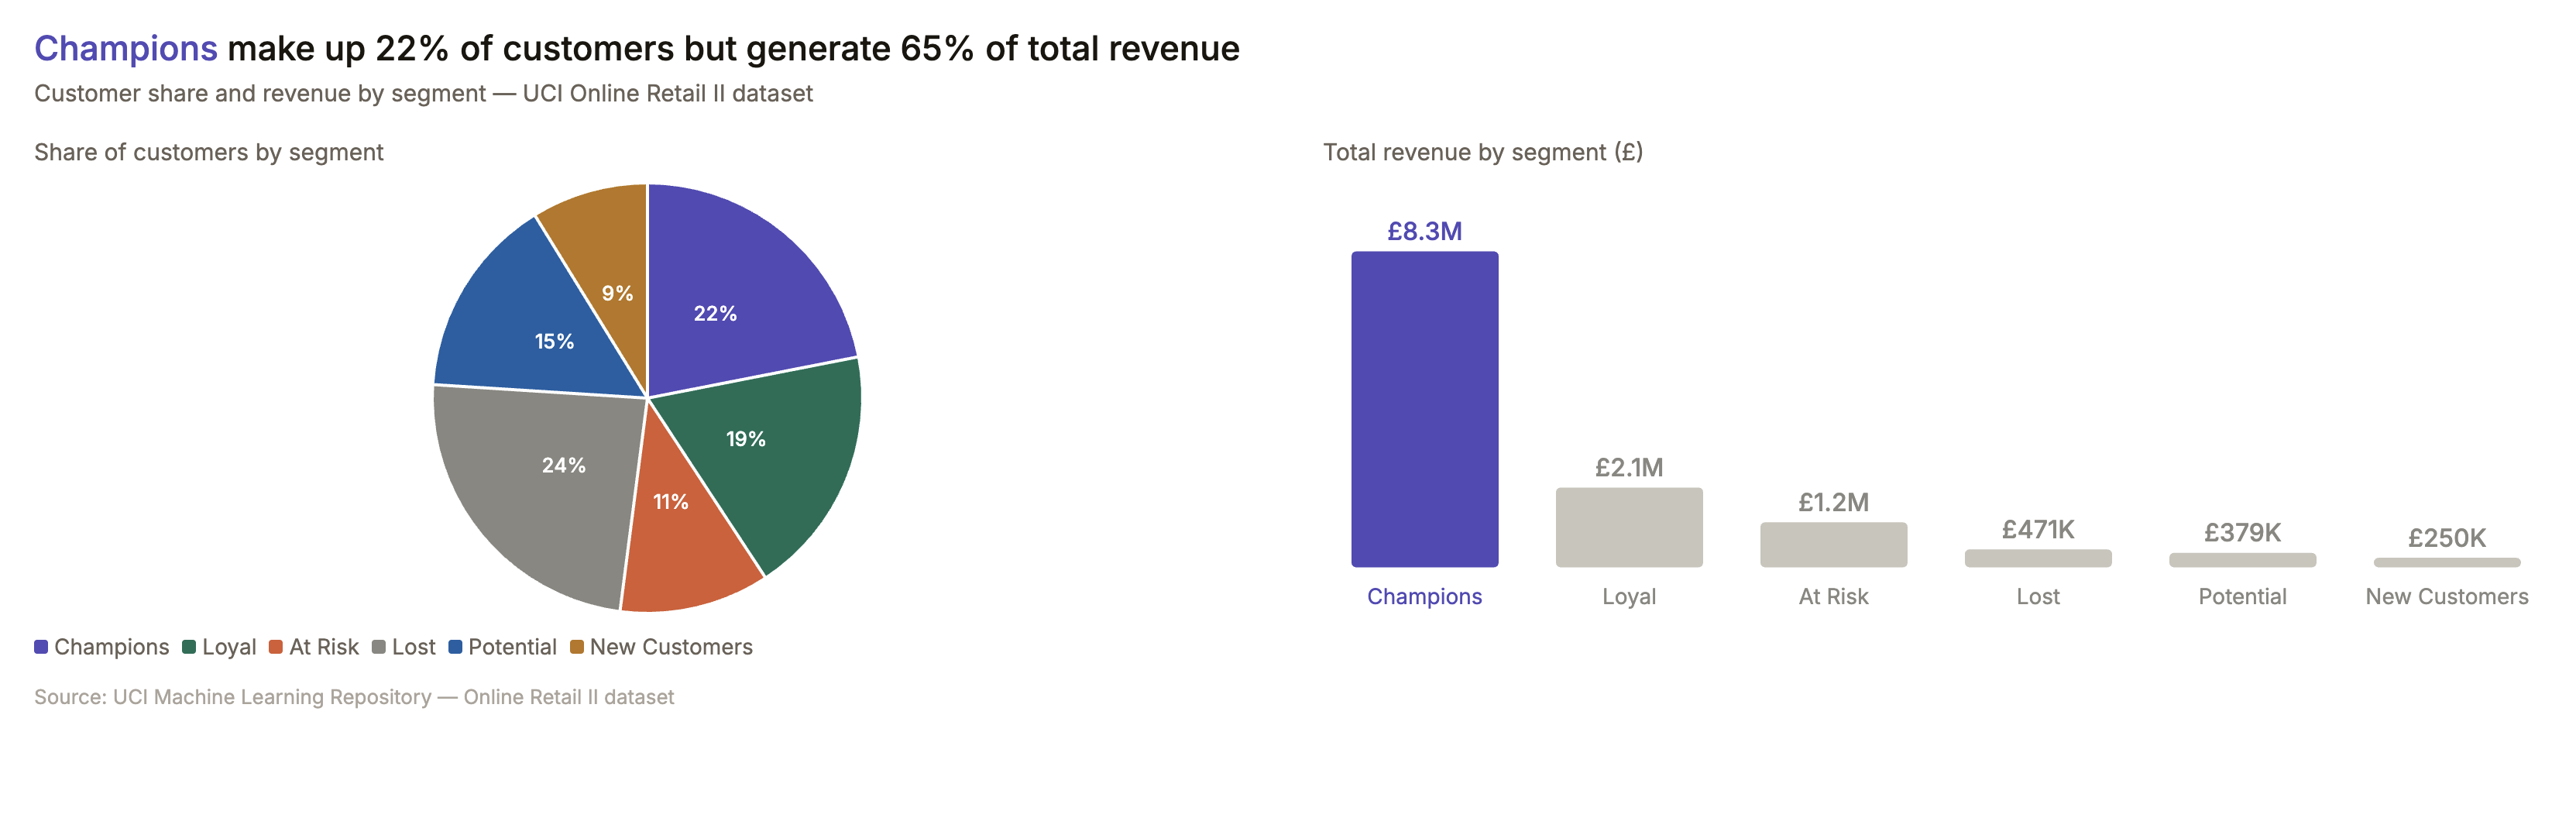

In [24]:
from IPython.display import Image
Image('../docs/img/rfm_segments.png')

## 5. Geographic Analysis

In [ ]:
# Top 10 Countries By Revenue

top_country_revenue = con.execute("""
    WITH country_stats AS (
        SELECT 
            Country,
            Sum(Revenue) as Revenue,
            COUNT(DISTINCT CustomerID) as Customers,
            COUNT(DISTINCT Invoice) as Orders
        FROM
            cleaned
        GROUP BY
            Country
        ORDER BY
            Sum(Revenue) DESC
        LIMIT 10
    )
    SELECT 
        *,
        (Revenue / (SELECT SUM(Revenue) FROM cleaned))*100 as "Market Share %",
        Orders/Customers as Order_Per_Customer
    FROM
        country_stats
""").fetchdf()

top_country_revenue

,Country,Revenue,Customers,Orders,Market Share %,Order_Per_Customer
0,United Kingdom,"12,656,167.76",5265,35037,86.53,6.65
1,EIRE,"398,572.95",3,568,2.73,189.33
2,Germany,"378,200.77",107,767,2.59,7.17
3,France,"291,565.69",93,605,1.99,6.51
4,Netherlands,"217,094.54",22,208,1.48,9.45
5,Switzerland,"84,253.72",22,86,0.58,3.91
6,Spain,"63,685.10",37,136,0.44,3.68
7,Belgium,"61,904.94",29,145,0.42,5.00
8,Australia,"60,556.48",15,84,0.41,5.60
9,Portugal,"45,747.92",23,84,0.31,3.65


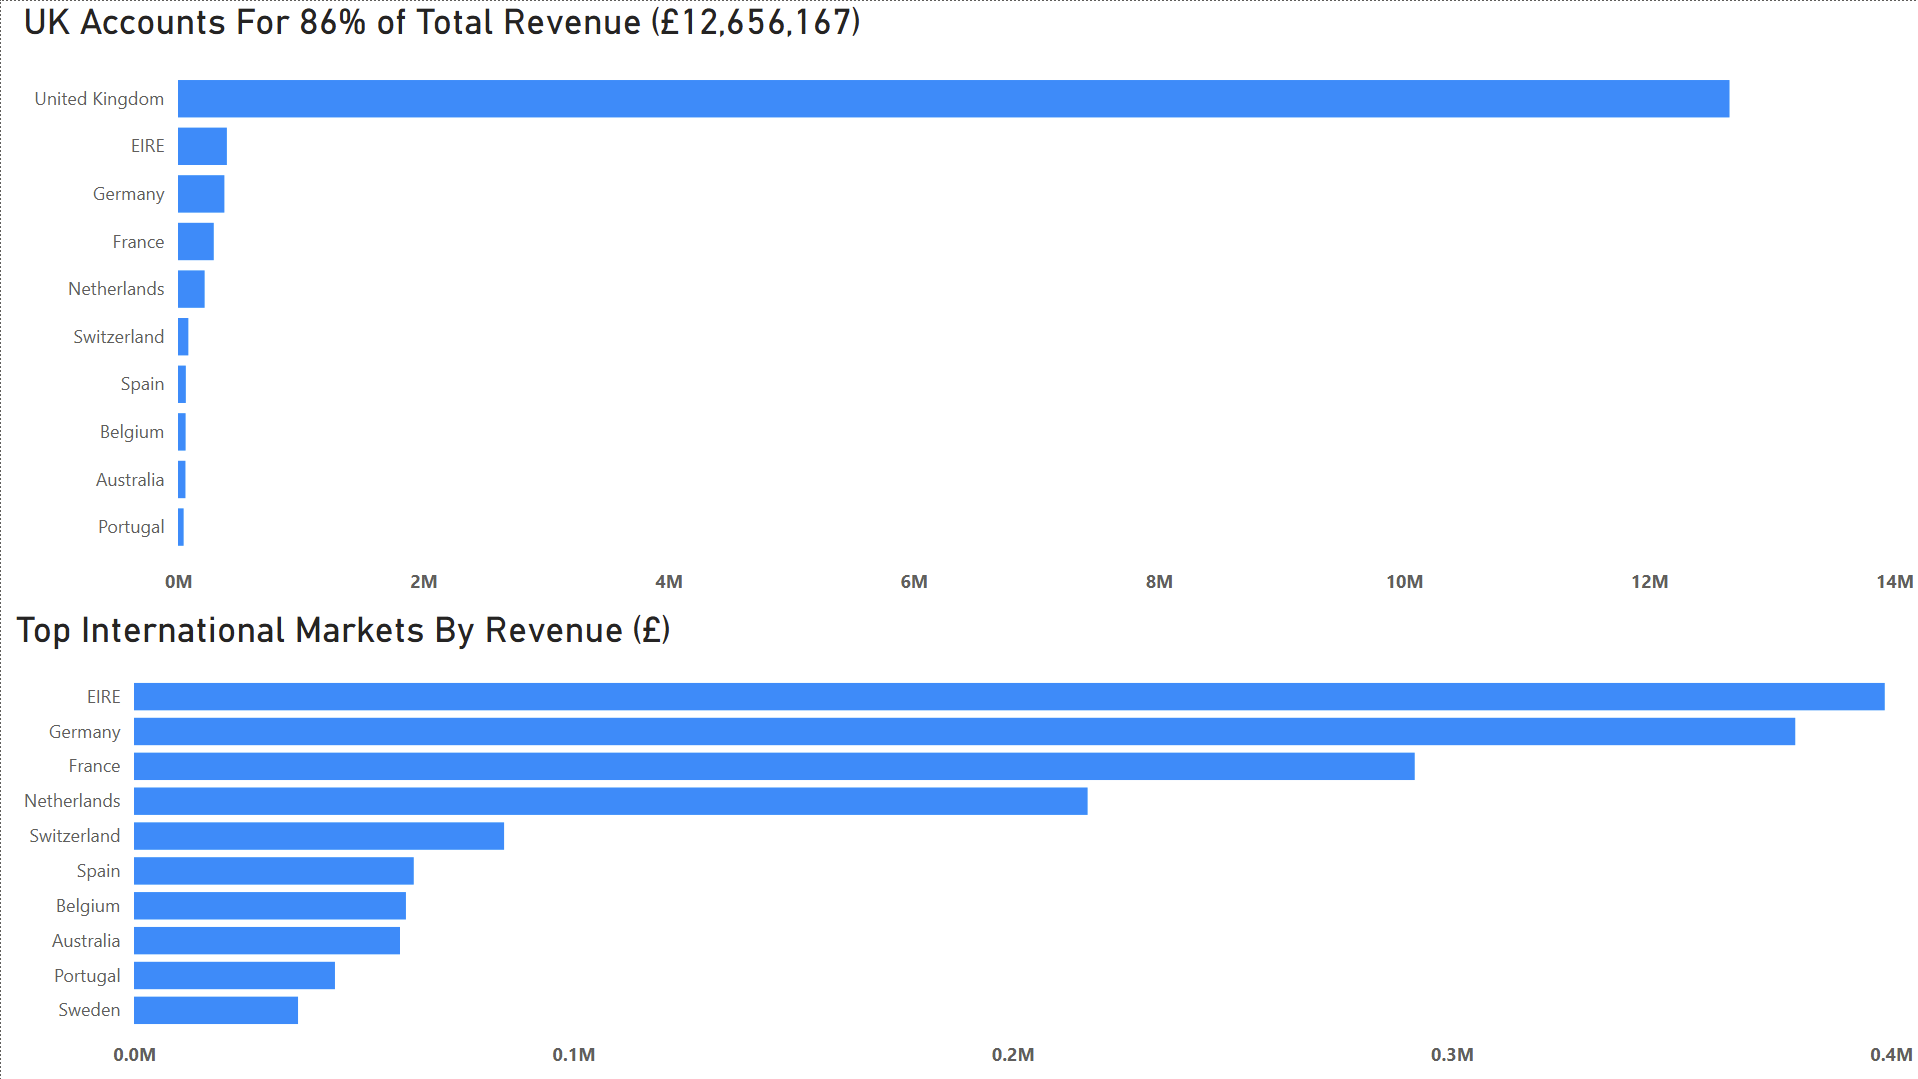

In [ ]:
from IPython.display import Image
Image('../docs/img/total_revenue_country.png', width=1000, height=600)

In [ ]:
# Customer Orders and Revenue in EIRE
con.execute("""
    SELECT 
        CustomerID,
        COUNT(DISTINCT Invoice) as Orders,
        SUM(Revenue) as Revenue
    FROM cleaned
    WHERE Country = 'EIRE'
    GROUP BY CustomerID
    ORDER BY SUM(Revenue) DESC
""").fetchdf()

,CustomerID,Orders,Revenue
0,"14,911.00",373,"245,187.45"
1,"14,156.00",131,"106,671.21"
2,NaN,53,"35,916.43"
3,"14,016.00",11,"10,797.86"


In [ ]:
# Customer Orders and Revenue in Germany
con.execute("""
    SELECT 
        CustomerID,
        COUNT(DISTINCT Invoice) as Orders,
        SUM(Revenue) as Revenue
    FROM cleaned
    WHERE Country = 'Germany'
    GROUP BY CustomerID
    ORDER BY SUM(Revenue) DESC
""").fetchdf()

,CustomerID,Orders,Revenue
0,"12,471.00",72,"32,530.30"
1,"12,709.00",32,"22,148.06"
2,"12,621.00",35,"20,466.52"
3,"12,477.00",9,"18,241.57"
4,"12,472.00",19,"16,219.34"
...,...,...,...
102,"12,622.00",1,180.10
103,"12,738.00",1,155.35
104,"12,603.00",1,126.00
105,"12,652.00",1,97.05


In [ ]:
# Customer Orders and Revenue in France
con.execute("""
    SELECT 
        CustomerID,
        COUNT(DISTINCT Invoice) as Orders,
        SUM(Revenue) as Revenue
    FROM cleaned
    WHERE Country = 'France'
    GROUP BY CustomerID
    ORDER BY SUM(Revenue) DESC
""").fetchdf()

,CustomerID,Orders,Revenue
0,"12,681.00",45,"29,574.36"
1,"12,682.00",52,"22,348.78"
2,"12,678.00",15,"19,734.26"
3,"12,731.00",17,"18,511.25"
4,"12,714.00",12,"14,093.71"
...,...,...,...
89,"12,602.00",1,153.12
90,"12,692.00",1,110.95
91,"12,659.00",1,91.68
92,"12,686.00",1,89.14


In [ ]:
# Customer Orders and Revenue in Netherlands
con.execute("""
    SELECT 
        CustomerID,
        COUNT(DISTINCT Invoice) as Orders,
        SUM(Revenue) as Revenue
    FROM cleaned
    WHERE Country = 'Netherlands'
    GROUP BY CustomerID
    ORDER BY SUM(Revenue) DESC
""").fetchdf()

,CustomerID,Orders,Revenue
0,"14,646.00",134,"193,095.27"
1,"12,759.00",8,"5,020.74"
2,"12,802.00",7,"2,287.94"
3,"12,806.00",3,"2,039.72"
4,"12,778.00",9,"1,775.68"
5,"12,775.00",7,"1,686.12"
6,"12,813.00",3,"1,435.80"
7,"12,805.00",4,"1,434.95"
8,"12,765.00",6,"1,404.58"
9,"12,803.00",1,"1,092.81"


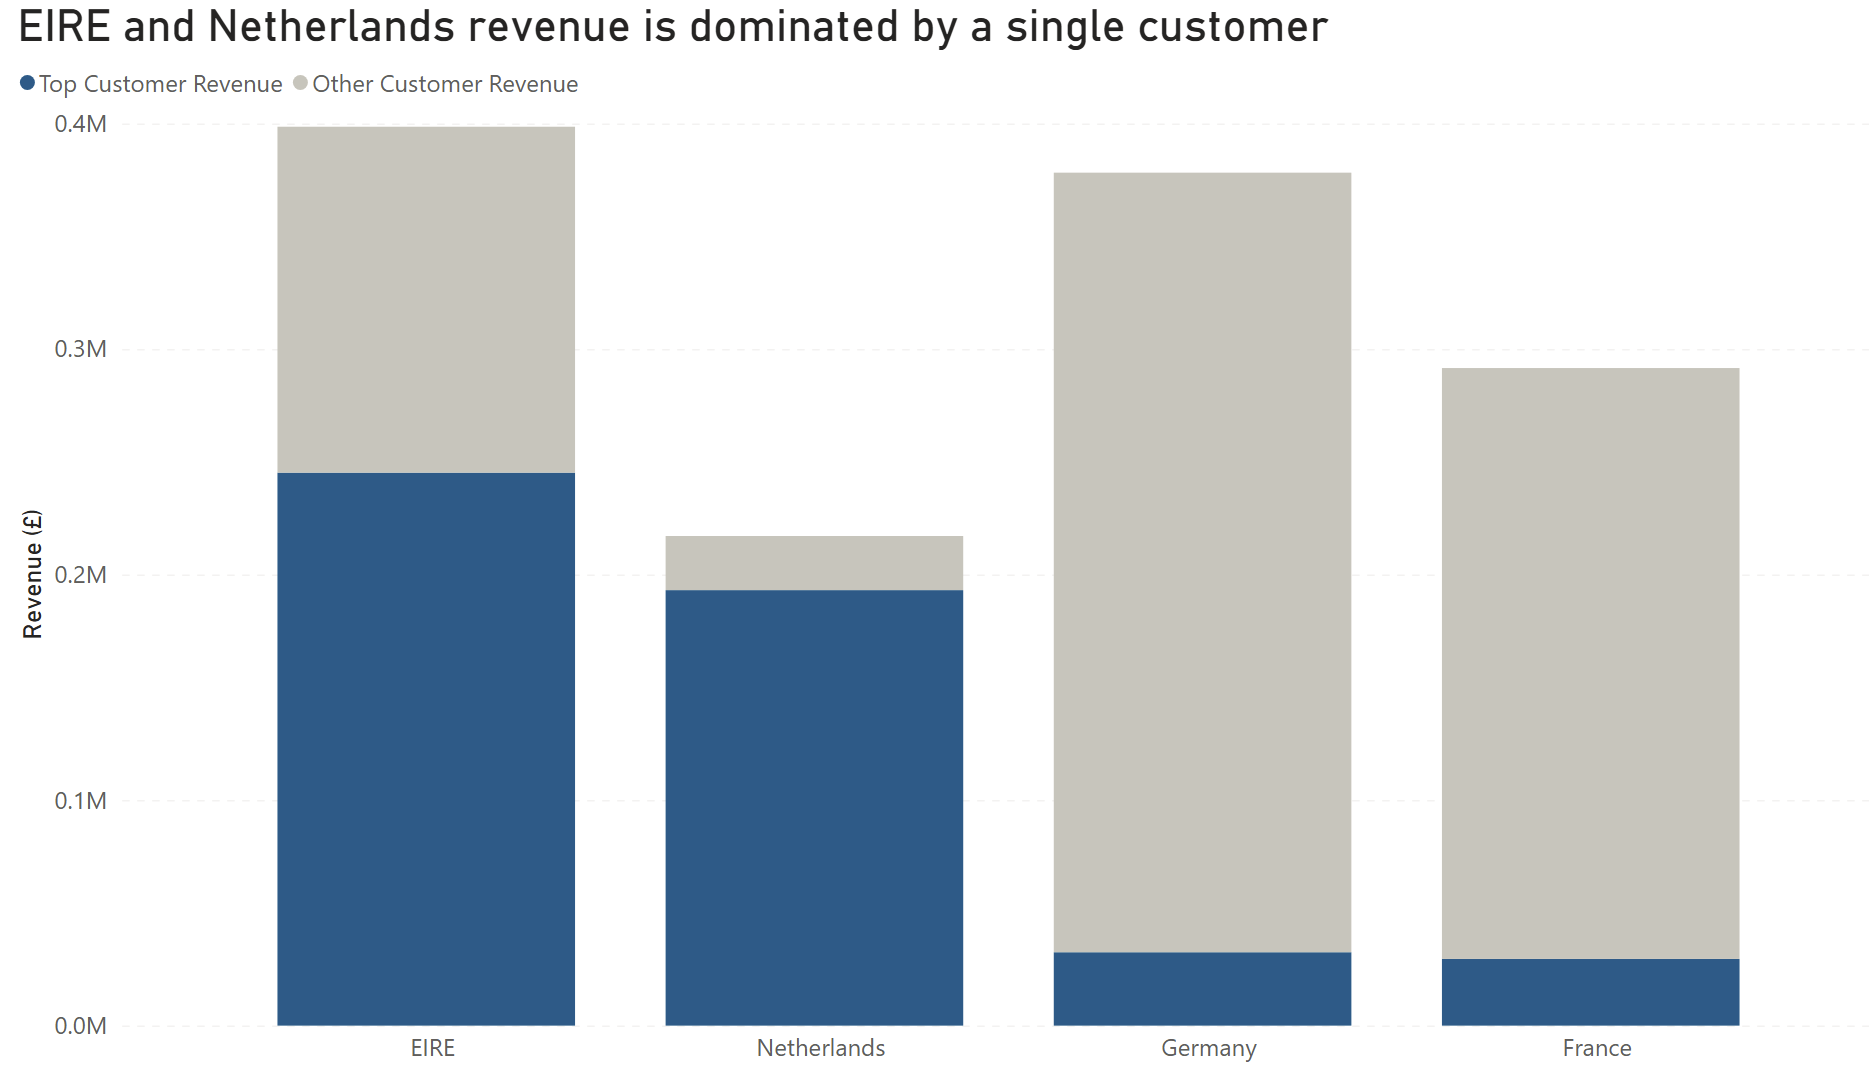

In [ ]:
Image('../docs/img/revenue_by_country.png', width=1000, height=600)

#### • EIRE generates the highest revenue by a non UK country but there are only 3 customers from that country suggesting wholesale/trade buyers placing enormous repeat orders.
#### • Netherlands has more unique customers than ireland but vast majority of orders being made by 1 customer

## 6. Product Analysis

In [ ]:
# Top 10 Products By Revenue

con.execute("""
    SELECT 
        StockCode,
        Description,
        Sum(Revenue) as Revenue,
        Sum(Quantity) as Quantity,
        COUNT(DISTINCT Invoice) as Orders
    FROM
        cleaned
    GROUP BY
        StockCode,
        Description
    ORDER BY
        Sum(Revenue) DESC
    LIMIT 10
""").fetchdf()

,StockCode,Description,Revenue,Quantity,Orders
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"172,201.54","61,860.00",5227
1,22423,REGENCY CAKESTAND 3 TIER,"171,361.78","14,407.00",3213
2,85099B,JUMBO BAG RED RETROSPOT,"100,338.57","51,436.00",3143
3,84879,ASSORTED COLOUR BIRD ORNAMENT,"75,321.42","43,926.00",2642
4,47566,PARTY BUNTING,"74,361.47","13,659.00",2453
5,POST,POSTAGE,"68,350.24","4,009.00",1417
6,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"59,055.46","18,643.00",1910
7,21931,JUMBO STORAGE BAG SUKI,"55,393.90","26,856.00",2313
8,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,"50,291.45","23,935.00",2173
9,85099F,JUMBO BAG STRAWBERRY,"47,819.22","25,275.00",1786


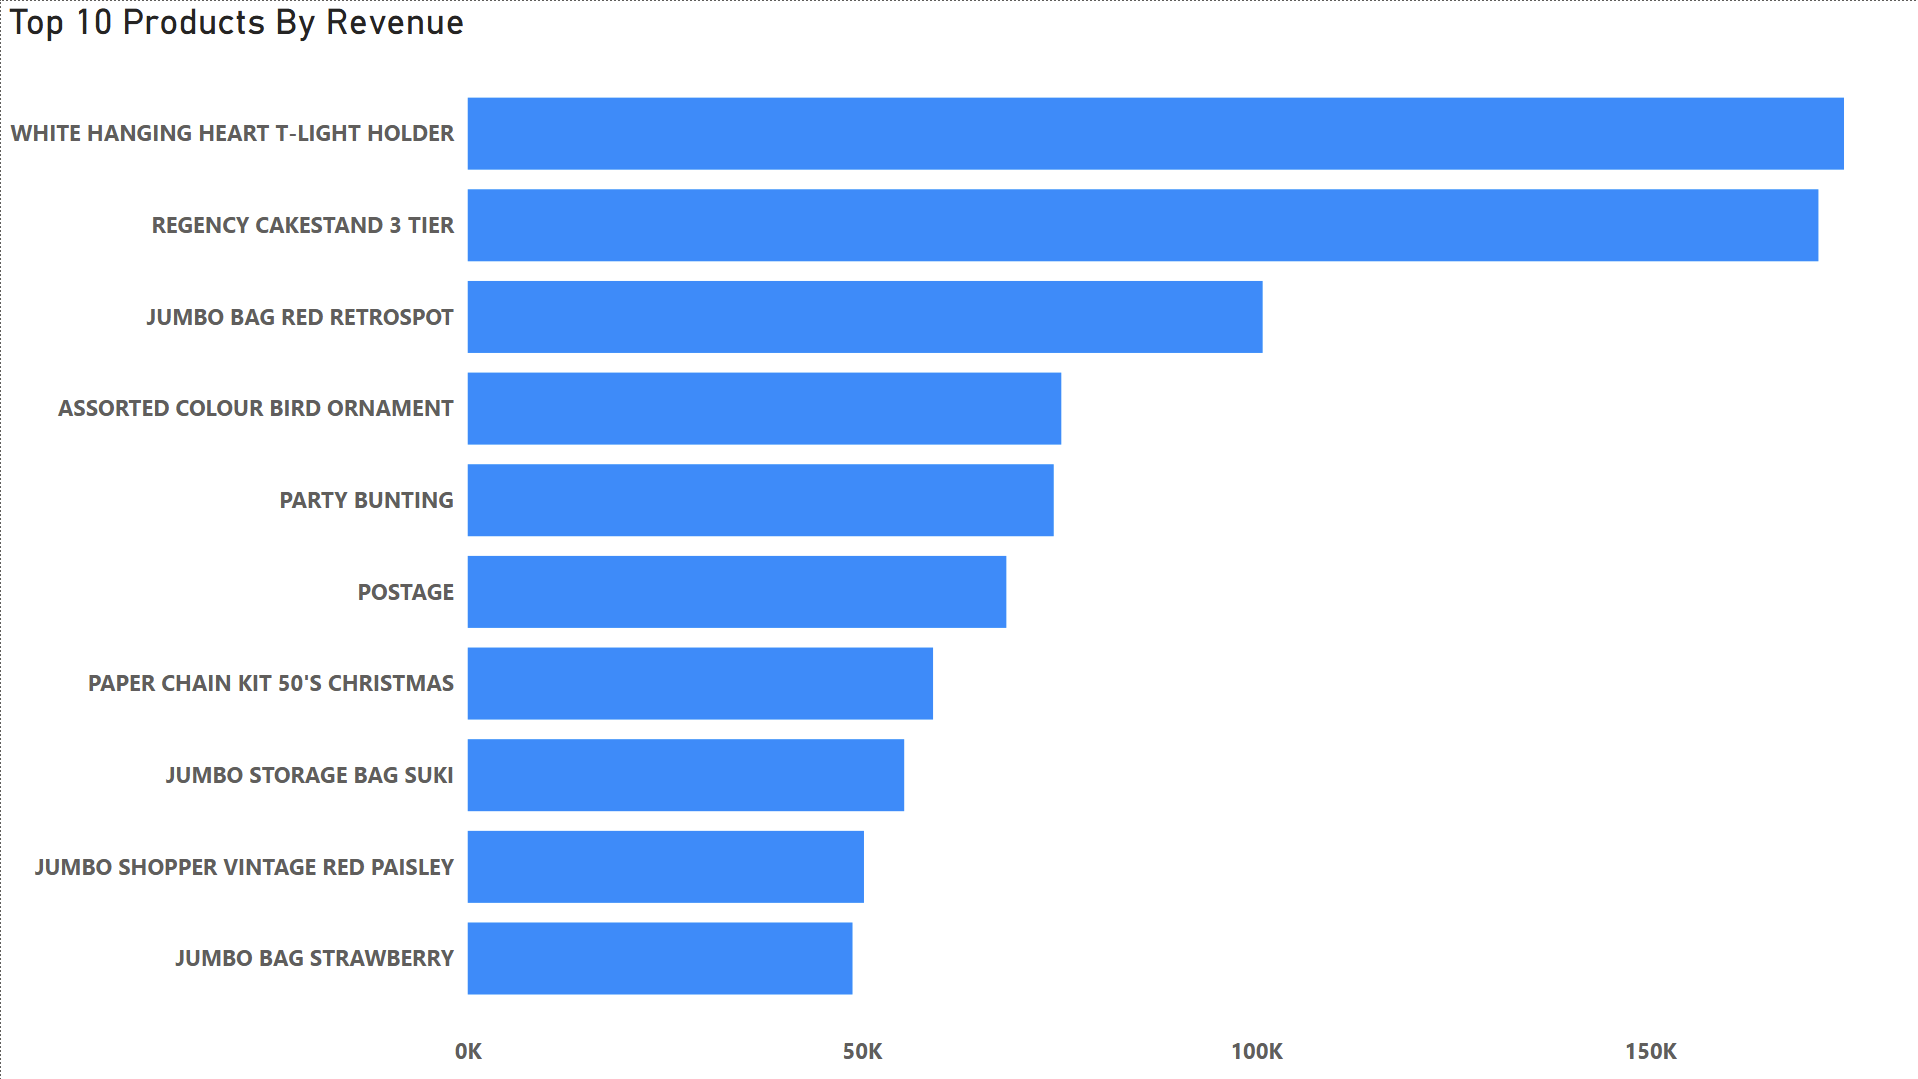

In [ ]:
from IPython.display import Image
Image('../docs/img/total_revenue_product.png', width=1000, height=600)

## 7. Time Patterns

In [ ]:
# Revenue By Day of Week
revenue_day = con.execute("""
    WITH day_of_week AS (
        SELECT
            *,
            CASE
                WHEN DayOfWeek = 0 Then 'Sunday'
                WHEN DayOfWeek = 1 Then 'Monday'
                WHEN DayOfWeek = 2 Then 'Tuesday'
                WHEN DayOfWeek = 3 Then 'Wednesday'
                WHEN DayOfWeek = 4 Then 'Thursday'
                WHEN DayOfWeek = 5 Then 'Friday'
                ELSE 'Saturday'
            END AS Days
        FROM
            cleaned
    )
    SELECT
        Days,
        Sum(Revenue) as Revenue
    FROM 
        day_of_week
    GROUP BY
        Days
    ORDER BY
        Revenue DESC
""").fetchdf()

revenue_day

,Days,Revenue
0,Thursday,"2,932,791.40"
1,Tuesday,"2,792,959.77"
2,Wednesday,"2,640,114.06"
3,Monday,"2,442,121.66"
4,Friday,"2,224,257.61"
5,Sunday,"1,584,195.74"
6,Saturday,"9,488.27"


In [ ]:
IFrame('../docs/img/revenue_by_day.html', width=900, height=520)

In [ ]:
# Revenue By Hour

revenue_hour = con.execute("""
    SELECT
        Hour,
        Sum(Revenue) as Revenue
    FROM 
        cleaned
    GROUP BY
        Hour
    ORDER BY
        Revenue DESC
""").fetchdf()

revenue_hour

,Hour,Revenue
0,12,"2,163,107.26"
1,13,"2,005,914.35"
2,14,"1,842,055.00"
3,10,"1,737,483.93"
4,11,"1,731,064.50"
5,15,"1,689,547.14"
6,9,"1,165,686.89"
7,16,"1,003,737.88"
8,17,"580,720.69"
9,8,"375,590.03"


In [ ]:
IFrame('../docs/img/revenue_by_hour.html', width=900, height=520)

## 8. Key Findings Summary

In [ ]:
print('=' * 60)
print('📊 KEY FINDINGS SUMMARY')
print('=' * 60)

uk_revenue = top_country_revenue.loc[top_country_revenue['Country'] == 'United Kingdom', 'Revenue'].values[0]
uk_share = (uk_revenue/totals['total_revenue'][0])*100

peak_day = revenue_day['Days'].iloc[0]
peak_hour = revenue_hour['Hour'].iloc[0]


print(f"""
1. REVENUE OVERVIEW
   • Total Revenue: £{totals['total_revenue'][0]:,.2f}
   • Total Orders: {totals['total_orders'][0]:,}
   • Average Order Value: £{totals['total_revenue'][0]/totals['total_orders'][0]:.2f}
   
2. SEASONALITY
   • November generates the highest average monthly revenue (holiday shopping)
   • Recommendation: Increase inventory by 40% in October

3. CUSTOMER SEGMENTS
   • Total Customers: {totals['total_customers'][0]:,}
   • {top_seg} generate {top_rev_pct}% of total revenue
   • Recommendation: Create VIP loyalty program for {top_seg}

4. GEOGRAPHIC INSIGHTS
   • UK: {uk_share:.0f}% of revenue
   • Top international: EIRE, Germany, France, Netherlands. Bulk of revenue in EIRE and Netherlands driven by 1 customer
   • Recommendation: Invest in EU marketing and fulfillment for Germany and France

5. TIMING PATTERNS
   • Peak day: {peak_day}
   • Peak hour: {int(peak_hour)}:00
   • Recommendation: Schedule campaigns around peak times

""")

📊 KEY FINDINGS SUMMARY

1. REVENUE OVERVIEW
   • Total Revenue: £14,625,928.52
   • Total Orders: 38,339
   • Average Order Value: £381.49

2. SEASONALITY
   • November generates the highest average monthly revenue (holiday shopping)
   • Recommendation: Increase inventory by 40% in October

3. CUSTOMER SEGMENTS
   • Total Customers: 5,780
   • Champions generate 65% of total revenue
   • Recommendation: Create VIP loyalty program for Champions

4. GEOGRAPHIC INSIGHTS
   • UK: 87% of revenue
   • Top international: EIRE, Germany, France, Netherlands. Bulk of revenue in EIRE and Netherlands driven by 1 customer
   • Recommendation: Invest in EU marketing and fulfillment for Germany and France

5. TIMING PATTERNS
   • Peak day: Thursday
   • Peak hour: 12:00
   • Recommendation: Schedule campaigns around peak times


